In [1]:
import numpy as np
from qccp_lasso import make_sample_dataset, sgs_lasso

In [2]:
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import make_regression

In [4]:
N = 1500
Q, c, lam = make_sample_dataset(N, cond=50)
x = np.zeros_like(c)

In [5]:
np.linalg.cond(Q)

49.999721671063035

In [6]:
lam

6.161263517889149

In [7]:
xstar, normgrads = sgs_lasso(x, Q, c, lam, maxiter=5000, tol=1e-6, verbose=True, debug=True)

relative norm: 0.000001 | tk: 4.894:   1%|          | 58/5000 [00:01<01:32, 53.39it/s] 


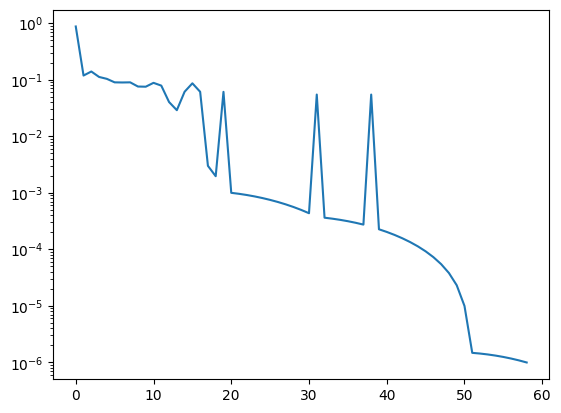

In [8]:
plt.plot(normgrads)
plt.yscale('log')

In [9]:
A, b, coef = make_regression(10000, 500, n_informative=250, noise=0.25, coef=True)

In [10]:
Q = A.T @ A
c = A.T @ b
x = np.zeros_like(c)

In [11]:
lmax = np.linalg.eigvalsh(Q).max()

In [12]:
lam = lmax * 0.125

In [13]:
xstar, normgrads = sgs_lasso(x, Q, c, lam, maxiter=100, tol=1e-6, verbose=True, debug=True)

relative norm: 0.000001 | tk: 1.000:   6%|▌         | 6/100 [00:00<00:00, 166.48it/s]


In [14]:
(xstar != 0).sum()

250

In [15]:
np.linalg.norm(xstar - coef, ord=np.inf)

0.27107202743270875

In [16]:
((xstar == 0) ^ (coef == 0)).sum()

0

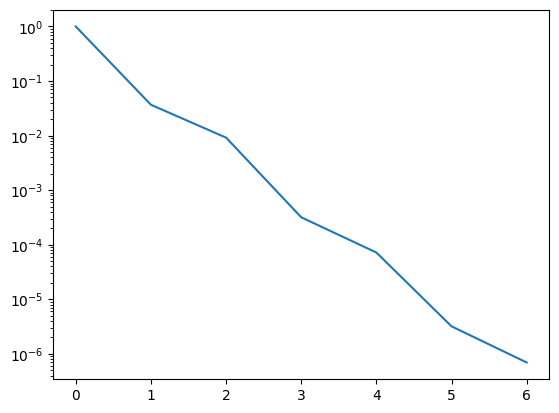

In [17]:
plt.plot(normgrads)
plt.yscale('log')